# Notebook 3 — Data Preprocessing & Feature Engineering
**CRISP-DM Phase 3 | Chapter 2: Data Preparation**

### Objectives
- Apply full DataCleaner pipeline (missing value handling, outlier capping)
- Demonstrate all MissingValueHandler strategies (class reference interface)
- Feature engineering: 7 domain-informed feature groups
- Build sklearn ColumnTransformer pipeline with stratified train/val/test splits
- Handle class imbalance (SMOTE demonstration — Chapter 2 reference)


## 1. Setup

In [20]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_cleaner import DataCleaner
from missing_value_handler import MissingValueHandler
from feature_enginner import FeatureEngineer
from data_preprocesor import DataPreprocessor

sns.set_theme(style='whitegrid')
COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
print("✓ Setup complete")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete


## 2. Load Raw Data

In [21]:
df_raw = pd.read_csv('../data/processed/all_waves_clean.csv')
print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.describe().round(2)


Loaded: 25,914 rows × 41 columns


,wave,settlement,zone_id,hh_size,adulteq,survey_weight,cons_quint,head_sex,head_age,head_age_sq,...,asset_count,housing_score,log_hh_size,dependency_ratio,assets_per_member,post_covid,is_tigray_conflict,has_full_housing,has_enterprise_data,household_id_w1
count,25914.00,25914.00,24458.00,25914.00,25914.00,25914.00,25349.00,25840.00,25819.00,25819.00,...,25914.00,25914.00,25914.00,25914.00,25914.00,25914.00,25914.0,25914.00,25914.00,3.776000e+03
mean,3.13,0.98,16693.40,4.54,3.71,3503.66,3.36,0.70,44.26,2193.79,...,0.12,0.36,1.61,0.18,0.03,0.19,0.0,0.55,0.55,5.255192e+12
std,1.35,0.85,20246.17,2.36,1.94,4258.24,1.44,0.46,15.33,1535.36,...,0.36,0.23,0.46,0.09,0.13,0.39,0.0,0.50,0.50,3.266976e+12
min,1.00,0.00,101.00,1.00,0.74,4.39,1.00,0.00,3.00,9.00,...,0.00,0.00,0.69,0.00,0.00,0.00,0.0,0.00,0.00,1.010102e+12
25%,2.00,0.00,2030.00,3.00,2.28,596.92,2.00,0.00,32.00,1024.00,...,0.00,0.19,1.39,0.11,0.00,0.00,0.0,0.00,0.00,3.051501e+12
50%,3.00,1.00,7160.00,4.00,3.49,1933.69,4.00,1.00,41.00,1681.00,...,0.00,0.44,1.61,0.18,0.00,0.00,0.0,1.00,1.00,4.121101e+12
75%,4.00,1.00,20304.00,6.00,4.92,4958.03,5.00,1.00,55.00,3025.00,...,0.00,0.55,1.95,0.24,0.00,0.00,0.0,1.00,1.00,7.070228e+12
max,5.00,3.00,72005.00,19.00,14.44,32753.24,5.00,1.00,100.00,10000.00,...,3.00,0.82,3.00,0.63,2.00,1.00,0.0,1.00,1.00,1.501020e+13


## 3. Missing Value Analysis — MissingValueHandler (Chapter 2 Reference)
The class reference (data_preprocessing.ipynb) demonstrates:
`detect_missing_values`, `stb.missing()`, individual imputation strategies.


In [22]:
handler = MissingValueHandler()

# Missing value report (class reference: detect_missing_values)
miss_df = handler.missing_report(df_raw)
print(f"Columns with missing values: {len(miss_df)}")
miss_df


Columns with missing values: 24


,feature,n_missing,pct_missing,dtype,recommended_strategy
0,household_id_w1,22138,85.43,float64,knn or median
1,owns_phone,16742,64.61,float64,flag_and_fill(0) [MNAR]
2,hh_avg_weeks_worked,12623,48.71,float64,0 for W2 [not working]; group_impute others
3,owns_fridge,11795,45.52,float64,flag_and_fill(0) [MNAR]
4,owns_tv,11795,45.52,float64,flag_and_fill(0) [MNAR]
5,roof,11793,45.51,float64,mode by settlement
6,fuel,11794,45.51,float64,mode by settlement
7,wall,11790,45.50,float64,mode by settlement
8,has_nonfarm_enterprise,11788,45.49,float64,flag_and_fill(0) [MNAR]
9,water,11787,45.49,float64,mode by settlement


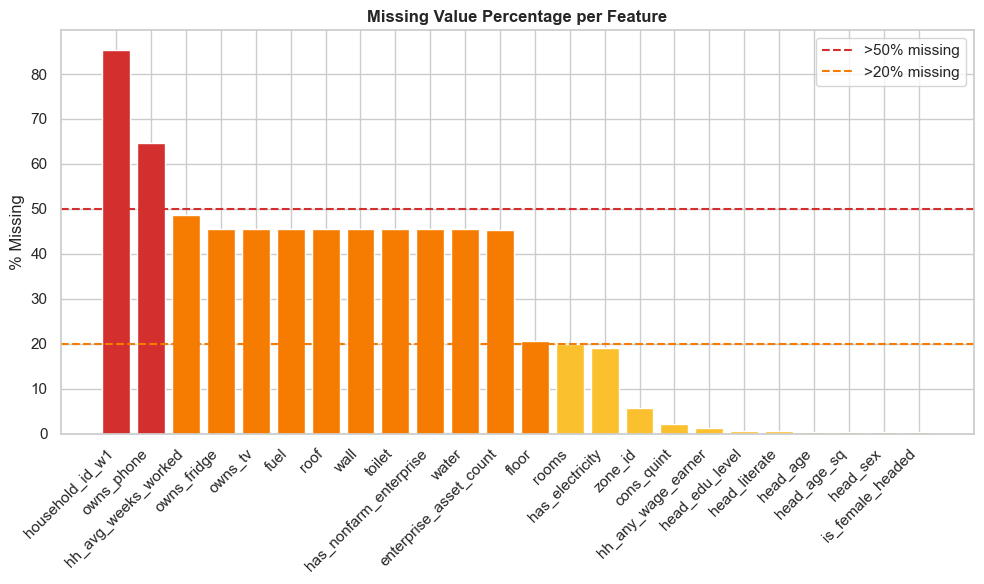

In [23]:
# Visualise missing value matrix (Chapter 2: data quality assessment)
fig, ax = plt.subplots(figsize=(10, 6))
miss_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
colors = ['#d32f2f' if v > 50 else '#f57c00' if v > 20 else '#fbc02d'
          for v in miss_pct.values]
ax.bar(miss_pct.index, miss_pct.values, color=colors, edgecolor='white')
ax.axhline(50, color='#d32f2f', ls='--', lw=1.5, label='>50% missing')
ax.axhline(20, color='#f57c00', ls='--', lw=1.5, label='>20% missing')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('% Missing')
ax.set_title('Missing Value Percentage per Feature', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.1 W2 Specific Missing Values — Cross-Wave Strategy
W2 (SPSS) has structurally sparse columns. Handle AFTER mixing all waves so
W1/W3 can serve as donor waves (same survey design, temporally adjacent).


In [24]:
# W2 vs other waves: null rates per column
w2     = df_raw[df_raw['wave']==2]
non_w2 = df_raw[df_raw['wave']!=2]
w2_gap_cols = ['head_age','rooms','hh_avg_weeks_worked',
               'head_age_sq','head_literate','is_female_headed']
w2_gap_cols = [c for c in w2_gap_cols if c in df_raw.columns]

print(f"{'Feature':<25} {'W2 null%':>10} {'Other null%':>12} {'Gap':>8}")
print("-" * 60)
for col in w2_gap_cols:
    w2_pct  = w2[col].isna().mean() * 100
    oth_pct = non_w2[col].isna().mean() * 100
    print(f"{col:<25} {w2_pct:>9.1f}% {oth_pct:>11.1f}% {w2_pct-oth_pct:>7.1f}pp")


Feature                     W2 null%  Other null%      Gap
------------------------------------------------------------
head_age                        0.2%         0.4%    -0.2pp
rooms                           1.3%        24.6%   -23.3pp
hh_avg_weeks_worked            51.2%        48.1%     3.2pp
head_age_sq                     0.2%         0.4%    -0.2pp
head_literate                   0.6%         0.6%     0.0pp
is_female_headed                0.0%         0.3%    -0.3pp


### 3.2 MissingValueHandler — Class-Reference Strategies Demo

In [25]:
# Demo all imputation strategies on a subset (class reference interface)
num_subset = df_raw.select_dtypes(include=[np.number]).copy()
num_subset = num_subset[['head_age','rooms','hh_avg_weeks_worked',
                          'housing_score','hh_n_workers']]
num_subset = num_subset[num_subset.isnull().any(axis=1)].head(200)
print(f"Demo subset: {num_subset.shape}  NaN cells: {num_subset.isnull().sum().sum()}")

strategies_demo = {}
for method in ['mean','median','mode','knn']:
    h = MissingValueHandler()
    result = h.impute(num_subset.copy(), method=method)
    remaining = result.isnull().sum().sum()
    strategies_demo[method] = remaining
    print(f"  {method:10s}: {remaining} NaN remaining")

print("\nRecommended for ESS: ess_pipeline()")


Demo subset: (200, 5)  NaN cells: 204
  mean      : 0 NaN remaining
  median    : 0 NaN remaining
  mode      : 0 NaN remaining
  knn       : 0 NaN remaining

Recommended for ESS: ess_pipeline()


## 4. Full Cleaning Pipeline — DataCleaner.fit_transform()
CRISP-DM Phase 2: the cleaning pipeline runs:
1. drop_missing_target → 2. impute (ess_pipeline) → 3. outliers → 4. flags → 5. variance filter


In [26]:
cleaner  = DataCleaner()
df_clean = cleaner.fit_transform(df_raw)
print(f"Before cleaning: {df_raw.shape}")
print(f"After  cleaning: {df_clean.shape}")
print(f"Nulls remaining: {df_clean.isnull().sum().sum()}")
print()
cleaner.report()


Before cleaning: (25914, 41)
After  cleaning: (25349, 40)
Nulls remaining: 0



,step,rows_dropped,rows_remaining,nulls_filled,nulls_remaining,values_capped,method,flags,dropped
0,drop_missing_target,565.0,25349.0,NaN,NaN,NaN,NaN,NaN,NaN
1,impute_missing,NaN,NaN,173181.0,0.0,NaN,NaN,NaN,NaN
2,handle_outliers,NaN,NaN,NaN,NaN,6452.0,IQR×3.0 per wave,NaN,NaN
3,add_coverage_flags,NaN,NaN,NaN,NaN,NaN,NaN,"[has_full_housing, has_enterprise_data]",NaN
4,drop_zero_variance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[is_tigray_conflict]


In [27]:
# Imputation log 
print("Imputation log:")
handler.imputation_log() if len(handler.log_) else cleaner.handler.imputation_log()


Imputation log:


,step,col,filled,remaining
0,wave_coverage_fill,owns_phone,16448,NaN
1,wave_coverage_fill,owns_tv,11738,NaN
2,wave_coverage_fill,owns_fridge,11738,NaN
3,wave_coverage_fill,has_electricity,4722,NaN
4,wave_coverage_fill,hh_any_wage_earner,341,NaN
5,wave_coverage_fill,has_nonfarm_enterprise,11731,NaN
6,wave_coverage_fill,enterprise_asset_count,11729,NaN
7,w2_weeks_fill,NaN,2586,NaN
8,w2_cross_wave_fill,head_age,8,0.0
9,w2_cross_wave_fill,head_age_sq,8,0.0


## 5. Feature Engineering — FeatureEngineer (7 Groups)
Chapter 2 reference: feature transformation, domain-informed interactions.


In [28]:
fe = FeatureEngineer()
df = fe.engineer_all(df_clean)

print(f"Before FE: {df_clean.shape[1]} columns")
print(f"After  FE: {df.shape[1]} columns  (+{len(fe.created_features_)} features)")
print()
fe.summary()


Before FE: 40 columns
After  FE: 59 columns  (+19 features)



,feature,description
0,adults_ratio,adulteq / hh_size — productive capacity
1,is_large_hh,1 if hh_size ≥ 7 — high dependency
2,is_single_person,1 if hh_size == 1 — isolated household
3,roof_quality,"1-(code-1)/5 [1=iron sheets, 0=grass]"
4,floor_quality,"recoded: earth=0, cement/tiles=1"
5,improved_water,1 if piped/borehole/protected source
6,improved_sanitation,1 if flush/VIP/pit-with-slab
7,clean_fuel,1 if electricity/gas/kerosene cooking fuel
8,housing_quality_idx,composite mean of housing quality sub-indices
9,modern_asset_score,phone×1 + TV×2 + fridge×3


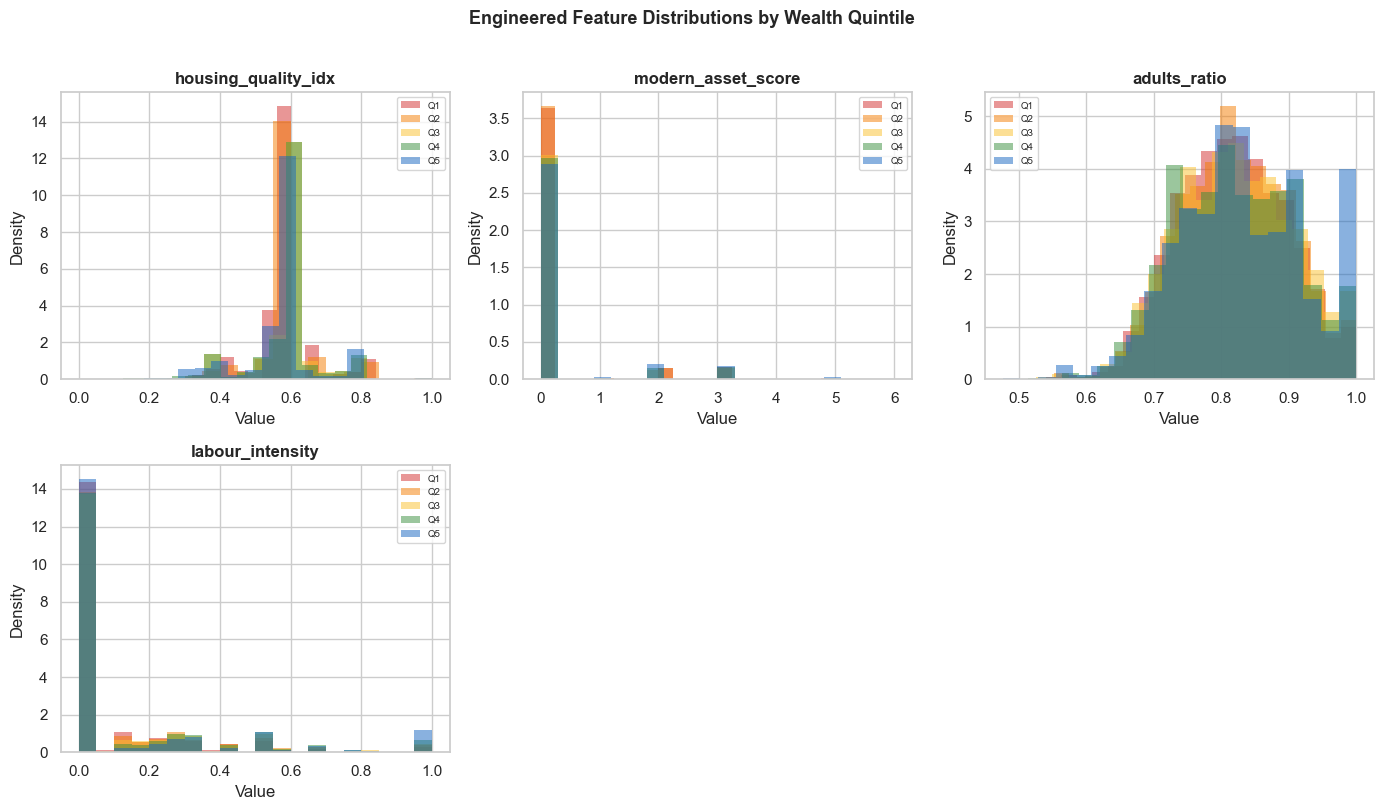

In [29]:
# Visualise new vs old feature distributions for key engineered features
eng_cols = ['housing_quality_idx','modern_asset_score','adults_ratio',
            'labour_intensity','shock_breadth']
eng_cols = [c for c in eng_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(eng_cols):
    ax = axes[i]
    for q, c in enumerate(COLORS5, 1):
        data = df.loc[df['cons_quint']==q, col].dropna()
        ax.hist(data, bins=20, color=c, alpha=0.5, label=f'Q{q}',
                density=True, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engineered Feature Distributions by Wealth Quintile',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Class Imbalance Check & SMOTE (Chapter 2 Reference)
The class reference (1_data_preprocessing.ipynb) demonstrates `handle_data_imbalance`.
Our target is roughly balanced (quintiles ~20% each), but we verify.


In [30]:
from collections import Counter

y = df['cons_quint'].dropna().astype(int)
print("Class distribution (cons_quint):")
for q, n in sorted(Counter(y).items()):
    pct = n/len(y)*100
    bar = '█' * int(pct/2)
    print(f"  Q{q}: {n:5,} ({pct:.1f}%) {bar}")

# Check if imbalance is severe (any class < 15%)
min_pct = min(v/len(y)*100 for v in Counter(y).values())
print(f"\nMin class share: {min_pct:.1f}%")
if min_pct < 15:
    print("⚠ Imbalance detected — SMOTE recommended for minority classes")
else:
    print("✓ Classes are sufficiently balanced — SMOTE not required")


Class distribution (cons_quint):
  Q1: 3,886 (15.3%) ███████
  Q2: 3,937 (15.5%) ███████
  Q3: 4,482 (17.7%) ████████
  Q4: 5,354 (21.1%) ██████████
  Q5: 7,690 (30.3%) ███████████████

Min class share: 15.3%
✓ Classes are sufficiently balanced — SMOTE not required


In [31]:
from collections import Counter

# SMOTE demonstration (Chapter 2 reference: handle_data_imbalance)
try:
    from imblearn.over_sampling import SMOTE

    feature_cols = [
        c for c in df.columns
        if c not in ('cons_quint', 'household_id', 'survey_weight')
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    if not feature_cols:
        print('SMOTE skipped (no numeric feature columns available).')
    else:
        X_sm = df.loc[df['cons_quint'].notna(), feature_cols].fillna(0).values
        y_sm = df.loc[df['cons_quint'].notna(), 'cons_quint'].astype(int).values

        class_counts = Counter(y_sm)
        min_class = min(class_counts.values()) if class_counts else 0

        if len(class_counts) < 2:
            print('SMOTE skipped (target has fewer than 2 classes).')
        elif min_class < 2:
            print(f'SMOTE skipped (smallest class has only {min_class} sample).')
        else:
            k_neighbors = min(5, min_class - 1)
            sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
            X_res, y_res = sm.fit_resample(X_sm, y_sm)
            print(f'Before SMOTE: {Counter(y_sm)}')
            print(f'After  SMOTE: {Counter(y_res)}')
except Exception as e:
    print(f'SMOTE skipped ({e}). Install imblearn: pip install imbalanced-learn')
    print('For ESS data, stratified sampling is sufficient (class balance ~20% each)')


Before SMOTE: Counter({np.int64(5): 7690, np.int64(4): 5354, np.int64(3): 4482, np.int64(2): 3937, np.int64(1): 3886})
After  SMOTE: Counter({np.int64(2): 7690, np.int64(1): 7690, np.int64(4): 7690, np.int64(3): 7690, np.int64(5): 7690})


## 7. DataPreprocessor — sklearn ColumnTransformer Pipeline
Chapter 2 reference: encoding + scaling + train/val/test splitting.


In [36]:
dp     = DataPreprocessor()
splits = dp.fit(df, test_size=0.20, val_size=0.15)

split_summary = pd.DataFrame([
    {'split':'Train',      'n': splits['split_sizes']['train'],
     'pct': f"{splits['split_sizes']['train']/sum(splits['split_sizes'].values())*100:.1f}%"},
    {'split':'Validation', 'n': splits['split_sizes']['val'],
     'pct': f"{splits['split_sizes']['val']/sum(splits['split_sizes'].values())*100:.1f}%"},
    {'split':'Test',       'n': splits['split_sizes']['test'],
     'pct': f"{splits['split_sizes']['test']/sum(splits['split_sizes'].values())*100:.1f}%"},
])
print(f"Feature matrix: {splits['X_train'].shape[1]} features")
print(f"Classes: {splits['label_classes']}")
print()
split_summary


Feature matrix: 65 features
Classes: [1 2 3 4 5]



,split,n,pct
0,Train,16476,65.0%
1,Validation,3803,15.0%
2,Test,5070,20.0%


In [33]:
# Feature group composition table
dp.feature_group_summary()


,group,n_defined,sample_features
0,Continuous,20,"hh_size, adulteq, head_age, head_age_sq, hh_n_..."
1,Binary,30,"head_sex, is_female_headed, head_literate, hh_..."
2,Ordinal,8,"roof, wall, floor, water, toilet…"
3,Nominal,2,"region, wave"


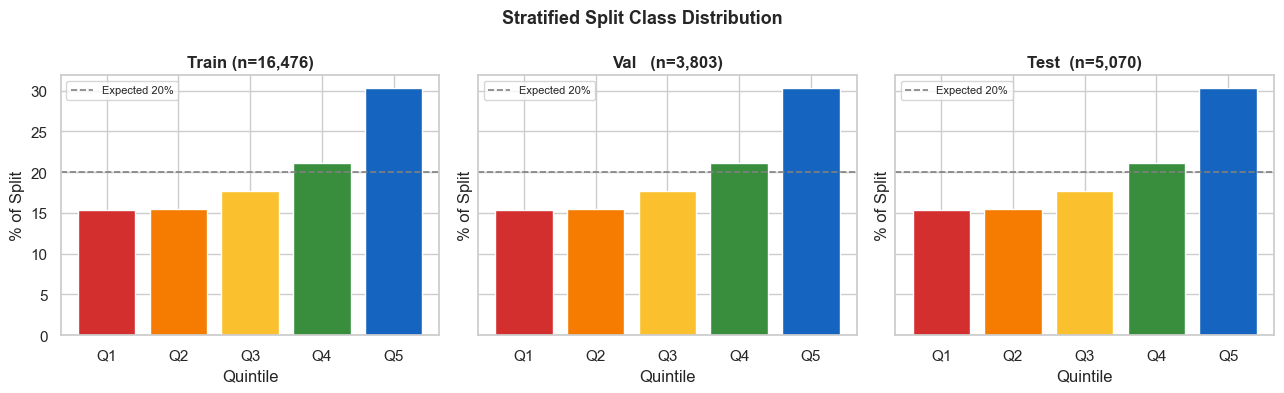

In [37]:
# Verify stratification — class balance in each split 
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
Q_LABELS = {1:'Q1',2:'Q2',3:'Q3',4:'Q4',5:'Q5'}

for ax, key, title in zip(axes,
    ['y_train','y_val','y_test'],
    [f"Train (n={splits['split_sizes']['train']:,})",
     f"Val   (n={splits['split_sizes']['val']:,})",
     f"Test  (n={splits['split_sizes']['test']:,})"]):
    y = splits[key]
    vals, cnts = np.unique(y, return_counts=True)
    ax.bar([Q_LABELS[v] for v in vals], cnts/len(y)*100,
           color=COLORS5, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.axhline(20, color='grey', ls='--', lw=1.2, label='Expected 20%')
    ax.set_ylabel('% of Split'); ax.set_xlabel('Quintile')
    ax.legend(fontsize=8)

plt.suptitle('Stratified Split Class Distribution', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/split_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# Save preprocessor
dp.save('../models/preprocessor.pkl')
print(f"Preprocessor saved. Feature count: {splits['n_features']}")


Preprocessor saved → ..\models\preprocessor.pkl
Preprocessor saved. Feature count: 65
